In [ ]:
import cv2
import numpy as np

img = cv2.imread('car.png')
cv2.imshow('Car image',img) #'Car image' - заголовок окна, img - переменная, содержащая изображение

if img is not None:
    print(f"Ширина - {img.shape[0]} px, высота - {img.shape[1]} px, количество каналов: {img.shape[2]}")
    # print(f"Прочитано изображение размером {img.shape}")
else:
    print("Ошибка чтения изображения")

cv2.waitKey(0) #ожидает нажатия любой клавиши
cv2.destroyAllWindows() #закроет окно перед завершением скрипта


Ширина - 1024 px, высота - 1792 px, количество каналов: 3


In [2]:
import cv2
import numpy as np

# Загрузка исходного изображения
image = cv2.imread('car.png')

# Проверка, что изображение загружено
if image is None:
    print("Изображение не прочитано")
    exit()

red_channel = image[:, :, 2]  # Красный канал
green_channel = image[:, :, 1]  # Зеленый канал
blue_channel = image[:, :, 0]  # Синий канал

# Сохранение изображений
cv2.imwrite('red_channel.jpg', red_channel)
cv2.imwrite('green_channel.jpg', green_channel)
cv2.imwrite('blue_channel.jpg', blue_channel)

print("Images saved successfully.")

Images saved successfully.


Это зеленый круг


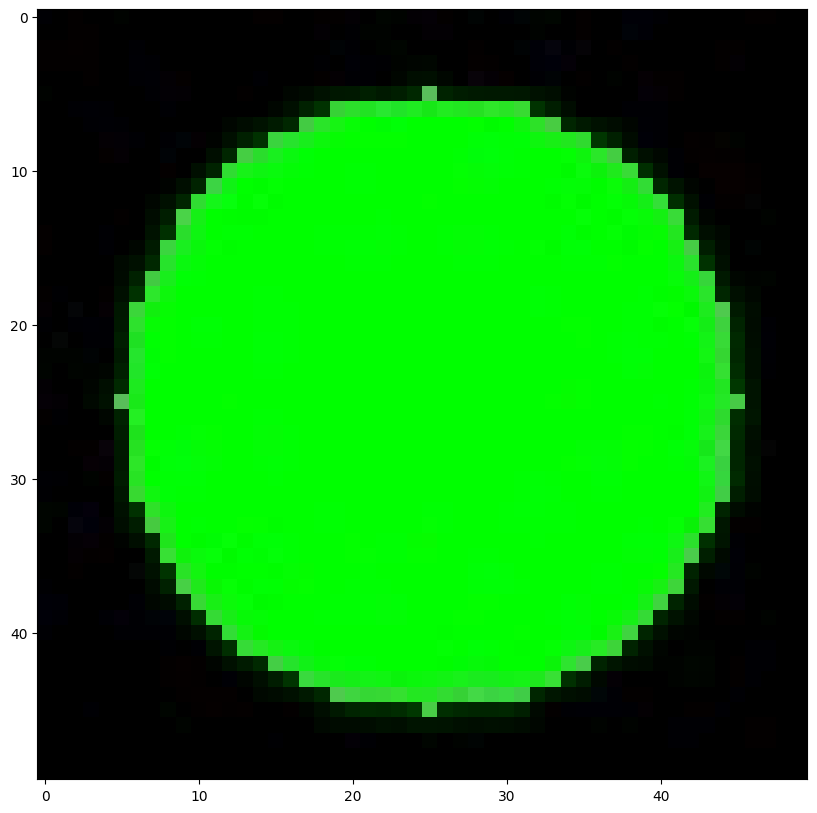

In [3]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

image = cv2.imread("084.jpg")
pixels = np.sum(image)

image = (np.where(image<3,0,image))
image = (np.where(image>253,255,image))

color = tuple(image[25:26, 25:26][0][0])
# print(color)
colors = {(0, 255, 0): 'зеленый', 
        (255, 255, 255): 'белый',
        (255, 255, 0): 'голубой',
        (0, 0, 255): 'красный',
        (255, 0, 0): "синий",
        (255, 0, 255): "фиолетовый",
        (0, 255, 255): "желтый"
}
print(f"Это {colors[color]} ", end='')


# 5. Классификация фигуры
top = np.sum(image[10:11, 5:6], axis=2)
bot = np.sum(image[42:43, 5:6],axis=2)

if bot and top:
    print('квадрат')
elif bot and not top:
    print('треугольник')
elif not bot and not top:
    print('круг')

plt.figure(figsize=(10,10))
plt.imshow(image[...,::-1])




In [15]:
image[0,0][0]

95

In [ ]:
import cv2

# Чтение изображения
image = cv2.imread('car.png')

# Преобразование в градации серого
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Сохранение результата
cv2.imwrite('gray_image.jpg', gray_image)

# Отображение результата
cv2.imshow('Gray Image', gray_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [13]:
gray_image.shape

(1024, 1792)

In [11]:
R = 125
G = 255
B = 102
Gray=round(0.299*R+0.587*G+0.114*B)

In [12]:
Gray

199

In [88]:
import cv2

from matplotlib import pyplot as plt

image = cv2.imread('./findShape/001.jpg')

hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Бинаризация изображения
# img_bin = np.where(img_gray > 15, 255, 0).astype(np.uint8)

img_bin = cv2.inRange(gray_image, 15, 255)

# Для нахождения контуров на бинаризованном изображении

cont, h = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

"""
img_bin — входное бинаризованное изображение.
cv2.RETR_EXTERNAL — режим извлечения, который извлекает только внешние контуры.
cv2.CHAIN_APPROX_SIMPLE — метод аппроксимации контуров, который удаляет все избыточные точки и сжимает контур, сохраняя его основную структуру.

Функция возвращает три значения:

_ — изображение с нарисованными контурами (не используется).
cont — список найденных контуров.
h — иерархия контуров (не используется).
"""

# Нахождение прямоугольника, ограничивающего объект

x, y, w, h = cv2.boundingRect(cont[0])

"""
cont[0] — первый найденный контур.
x, y — координаты верхнего левого угла прямоугольника.
w, h — ширина и высота прямоугольника.
"""

# Вычисление координат центра объекта

center_x = x + w // 2 
center_y = y + h // 2

h, s, v = hsv_img[center_y, center_x]

print(f'H: {h} S: {s} V: {v}')
# cv2.imshow('Gray Image', gray_image)

# cv2.waitKey(0)
# cv2.destroyAllWindows()


H: 90 S: 255 V: 255


In [82]:
print(center_x, center_y)

370 114


In [86]:
h_img = hsv_img[center_y, center_x]

In [87]:
h_img

array([ 90, 255, 255], dtype=uint8)